In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/results_global.csv")
print(df.head())

         instance  run   n  alg        test  initial_f  best_f  delta  \
0  Cebe.lop.n10.1    1  10  ILS   ils_suave       2096    2384    288   
1  Cebe.lop.n10.1    2  10  ILS   ils_suave       1541    2384    843   
2  Cebe.lop.n10.1    3  10  ILS   ils_suave       1428    2384    956   
3  Cebe.lop.n10.1    1  10  ILS  ils_fuerte       2096    2384    288   
4  Cebe.lop.n10.1    2  10  ILS  ils_fuerte       1541    2384    843   

   delta_rel      time  valid_perm  
0   0.137405  0.181105        True  
1   0.547047  0.186901        True  
2   0.669468  0.297164        True  
3   0.137405  0.234349        True  
4   0.547047  0.215699        True  


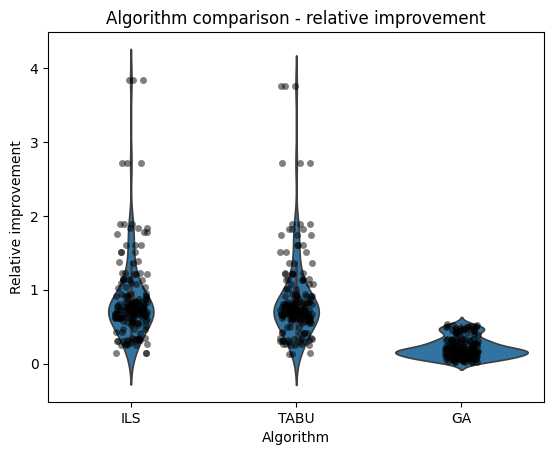

In [3]:
plt.figure()

sns.violinplot(
    data=df,
    x="alg",
    y="delta_rel"
)

sns.stripplot(
    data=df,
    x="alg",
    y="delta_rel",
    color="black",
    alpha=0.5
)

plt.title("Algorithm comparison - relative improvement")
plt.ylabel("Relative improvement")
plt.xlabel("Algorithm")

plt.show()

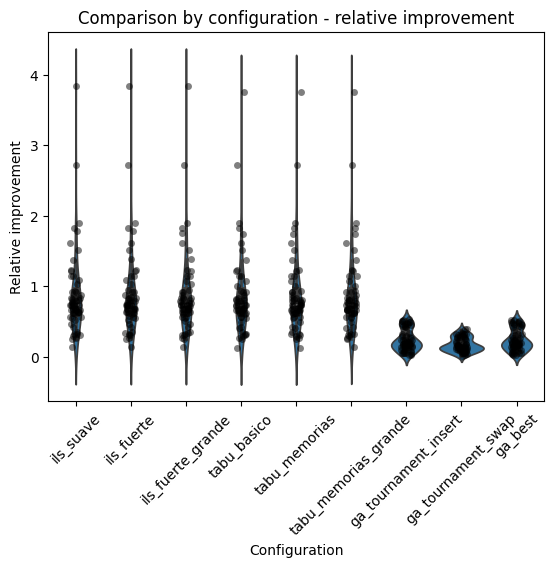

In [4]:
plt.figure()

sns.violinplot(
    data=df,
    x="test",
    y="delta_rel"
)

sns.stripplot(
    data=df,
    x="test",
    y="delta_rel",
    color="black",
    alpha=0.5
)

plt.xticks(rotation=45)
plt.title("Comparison by configuration - relative improvement")
plt.ylabel("Relative improvement")
plt.xlabel("Configuration")
plt.show()

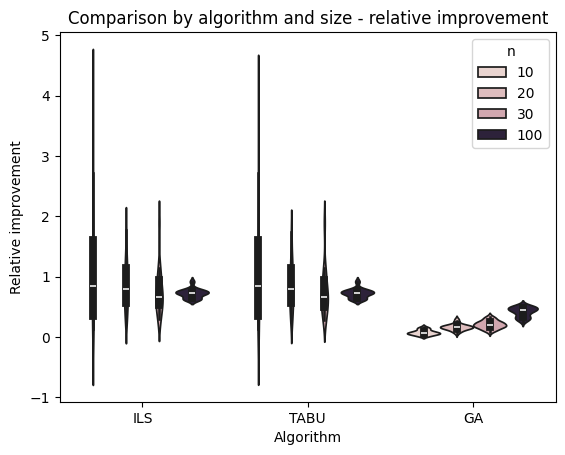

In [5]:
plt.figure()

sns.violinplot(
    data=df,
    x="alg",
    y="delta_rel",
    hue="n"
)

plt.title("Comparison by algorithm and size - relative improvement")
plt.ylabel("Relative improvement")
plt.xlabel("Algorithm")
plt.show()

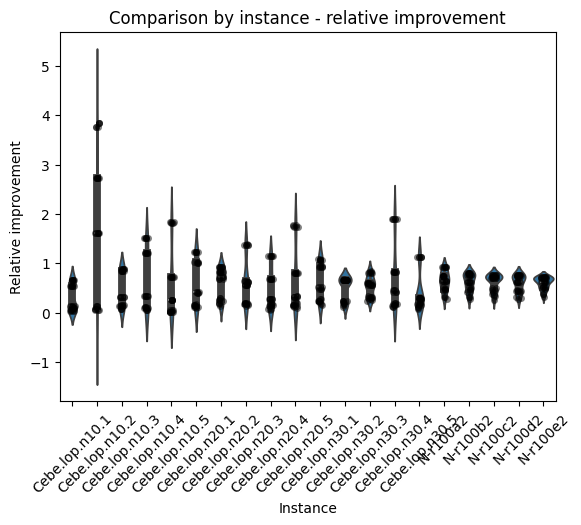

In [6]:
plt.figure()

sns.violinplot(
    data=df,
    x="instance",
    y="delta_rel"
)

sns.stripplot(
    data=df,
    x="instance",
    y="delta_rel",
    color="black",
    alpha=0.5
)

plt.xticks(rotation=45)
plt.title("Comparison by instance - relative improvement")
plt.ylabel("Relative improvement")
plt.xlabel("Instance")
plt.show()

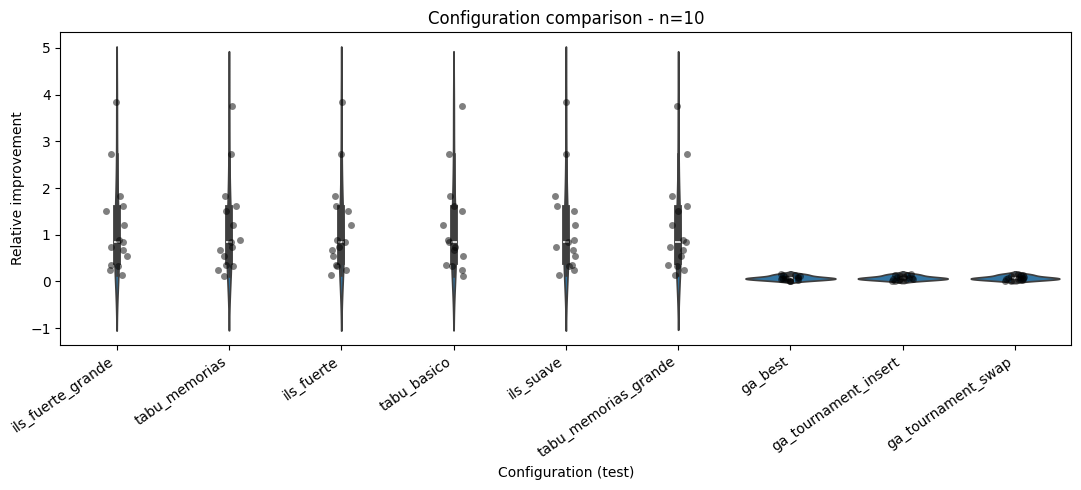

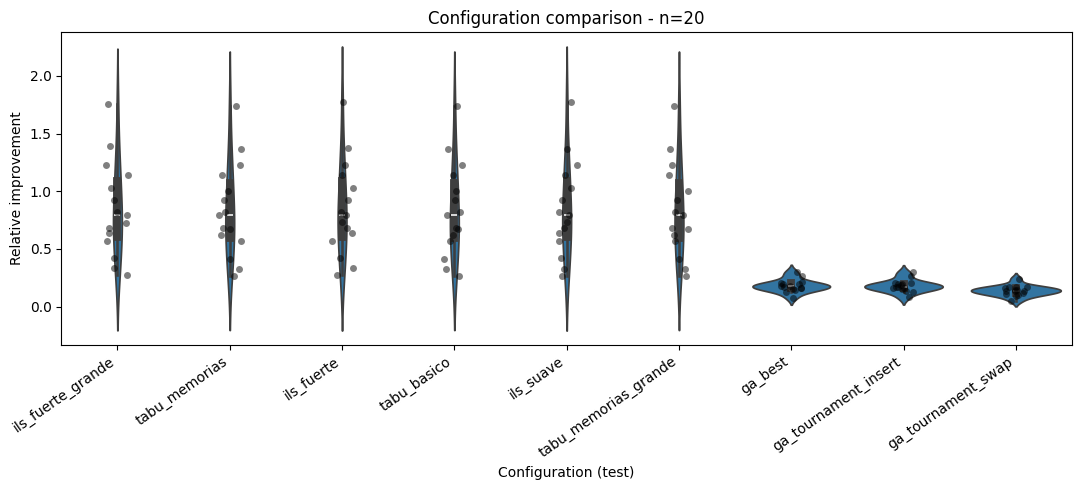

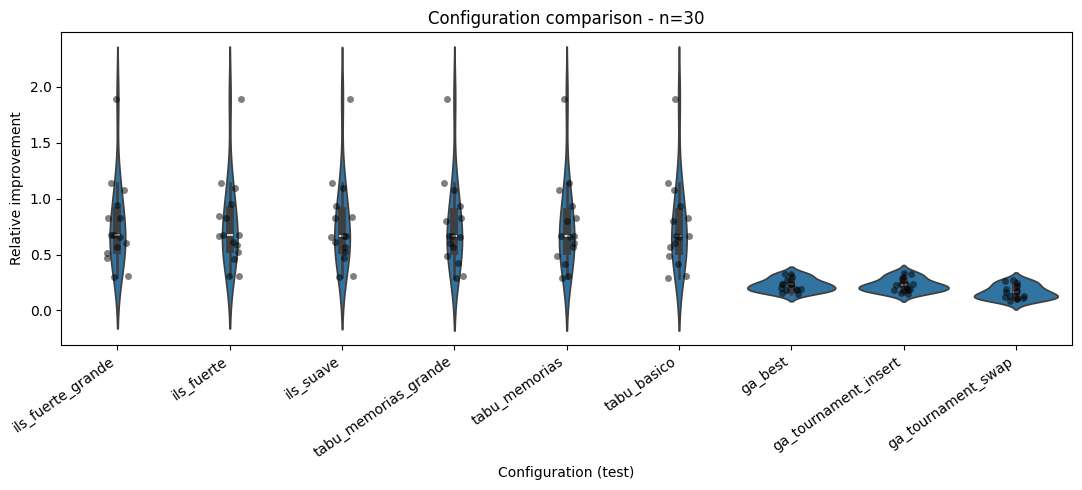

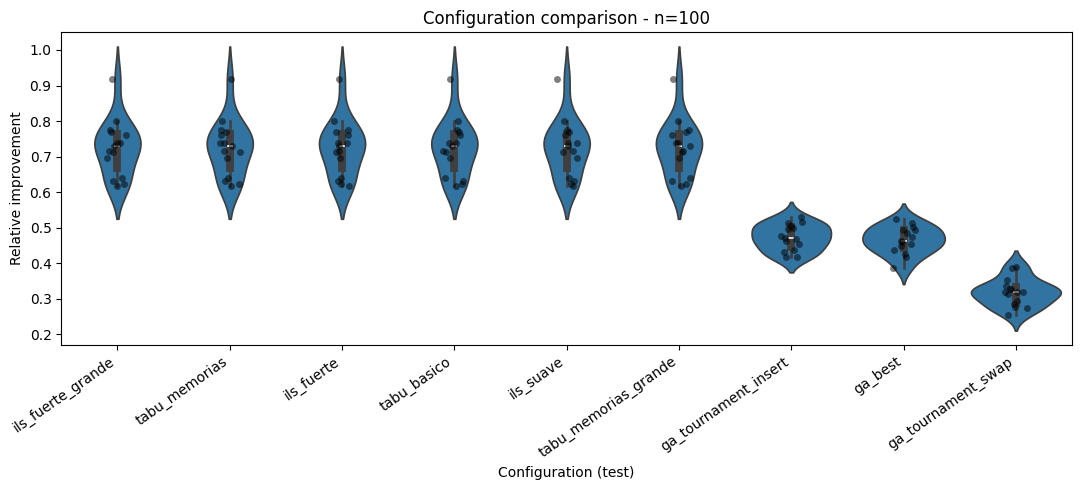

In [7]:
# One graph per matrix size (n): compare delta across configurations (test)
metric = "delta_rel" if "delta_rel" in df.columns else "delta"

for n_value in sorted(df["n"].dropna().unique()):
    subset = df[df["n"] == n_value].copy()
    if subset.empty:
        continue

    order = subset.groupby("test")[metric].median().sort_values(ascending=False).index

    plt.figure(figsize=(11, 5))

    sns.violinplot(
        data=subset,
        x="test",
        y=metric,
        order=order
    )

    sns.stripplot(
        data=subset,
        x="test",
        y=metric,
        order=order,
        color="black",
        alpha=0.5
    )

    plt.title(f"Configuration comparison - n={int(n_value)}")
    plt.xlabel("Configuration (test)")
    plt.ylabel("Relative improvement" if metric == "delta_rel" else "Improvement (delta)")
    plt.xticks(rotation=35, ha="right")

    plt.tight_layout()
    plt.show()
